In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url = "https://books.toscrape.com/"

response = requests.get(url)

print(response.status_code)

200


In [3]:
soup = BeautifulSoup(response.text, "html.parser")

print(soup.title.text)


    All products | Books to Scrape - Sandbox



In [4]:
books = soup.find_all("article", class_="product_pod")

print("Number of books:", len(books))

Number of books: 20


In [5]:
first_book = books[0]

print(first_book.h3.a["title"])
print(first_book.find("p", class_="price_color").text)
print(first_book.find("p", class_="star-rating")["class"][1])
print(first_book.h3.a["href"])

A Light in the Attic
Â£51.77
Three
catalogue/a-light-in-the-attic_1000/index.html


In [6]:
data = []

for book in books:

    title = book.h3.a["title"]

    price = book.find(
        "p",
        class_="price_color"
    ).text

    rating = book.find(
        "p",
        class_="star-rating"
    )["class"][1]

    book_url = book.h3.a["href"]

    data.append({
        "Title": title,
        "Price": price,
        "Rating": rating,
        "URL": book_url
    })

df = pd.DataFrame(data)

df.head()

,Title,Price,Rating,URL
0,A Light in the Attic,Â£51.77,Three,catalogue/a-light-in-the-attic_1000/index.html
1,Tipping the Velvet,Â£53.74,One,catalogue/tipping-the-velvet_999/index.html
2,Soumission,Â£50.10,One,catalogue/soumission_998/index.html
3,Sharp Objects,Â£47.82,Four,catalogue/sharp-objects_997/index.html
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,catalogue/sapiens-a-brief-history-of-humankind...


In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

df.head()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Rows: 20
Columns: 4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   20 non-null     object
 1   Price   20 non-null     object
 2   Rating  20 non-null     object
 3   URL     20 non-null     object
dtypes: object(4)
memory usage: 772.0+ bytes

Missing Values:
Title     0
Price     0
Rating    0
URL       0
dtype: int64

Duplicate Rows:
0


In [9]:
df["Price"] = df["Price"].str.replace("Â£", "", regex=False).astype(float)

df.head()

,Title,Price,Rating,URL
0,A Light in the Attic,51.77,Three,catalogue/a-light-in-the-attic_1000/index.html
1,Tipping the Velvet,53.74,One,catalogue/tipping-the-velvet_999/index.html
2,Soumission,50.10,One,catalogue/soumission_998/index.html
3,Sharp Objects,47.82,Four,catalogue/sharp-objects_997/index.html
4,Sapiens: A Brief History of Humankind,54.23,Five,catalogue/sapiens-a-brief-history-of-humankind...


In [10]:
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Title   20 non-null     object 
 1   Price   20 non-null     float64
 2   Rating  20 non-null     object 
 3   URL     20 non-null     object 
dtypes: float64(1), object(3)
memory usage: 772.0+ bytes
None

Missing Values:
Title     0
Price     0
Rating    0
URL       0
dtype: int64


In [11]:
df.to_csv("books_scraped.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [12]:
df.head(10)

,Title,Price,Rating,URL
0,A Light in the Attic,51.77,Three,catalogue/a-light-in-the-attic_1000/index.html
1,Tipping the Velvet,53.74,One,catalogue/tipping-the-velvet_999/index.html
2,Soumission,50.10,One,catalogue/soumission_998/index.html
3,Sharp Objects,47.82,Four,catalogue/sharp-objects_997/index.html
4,Sapiens: A Brief History of Humankind,54.23,Five,catalogue/sapiens-a-brief-history-of-humankind...
5,The Requiem Red,22.65,One,catalogue/the-requiem-red_995/index.html
6,The Dirty Little Secrets of Getting Your Dream...,33.34,Four,catalogue/the-dirty-little-secrets-of-getting-...
7,The Coming Woman: A Novel Based on the Life of...,17.93,Three,catalogue/the-coming-woman-a-novel-based-on-th...
8,The Boys in the Boat: Nine Americans and Their...,22.60,Four,catalogue/the-boys-in-the-boat-nine-americans-...
9,The Black Maria,52.15,One,catalogue/the-black-maria_991/index.html


/tmp/ipykernel_1216/4212088715.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


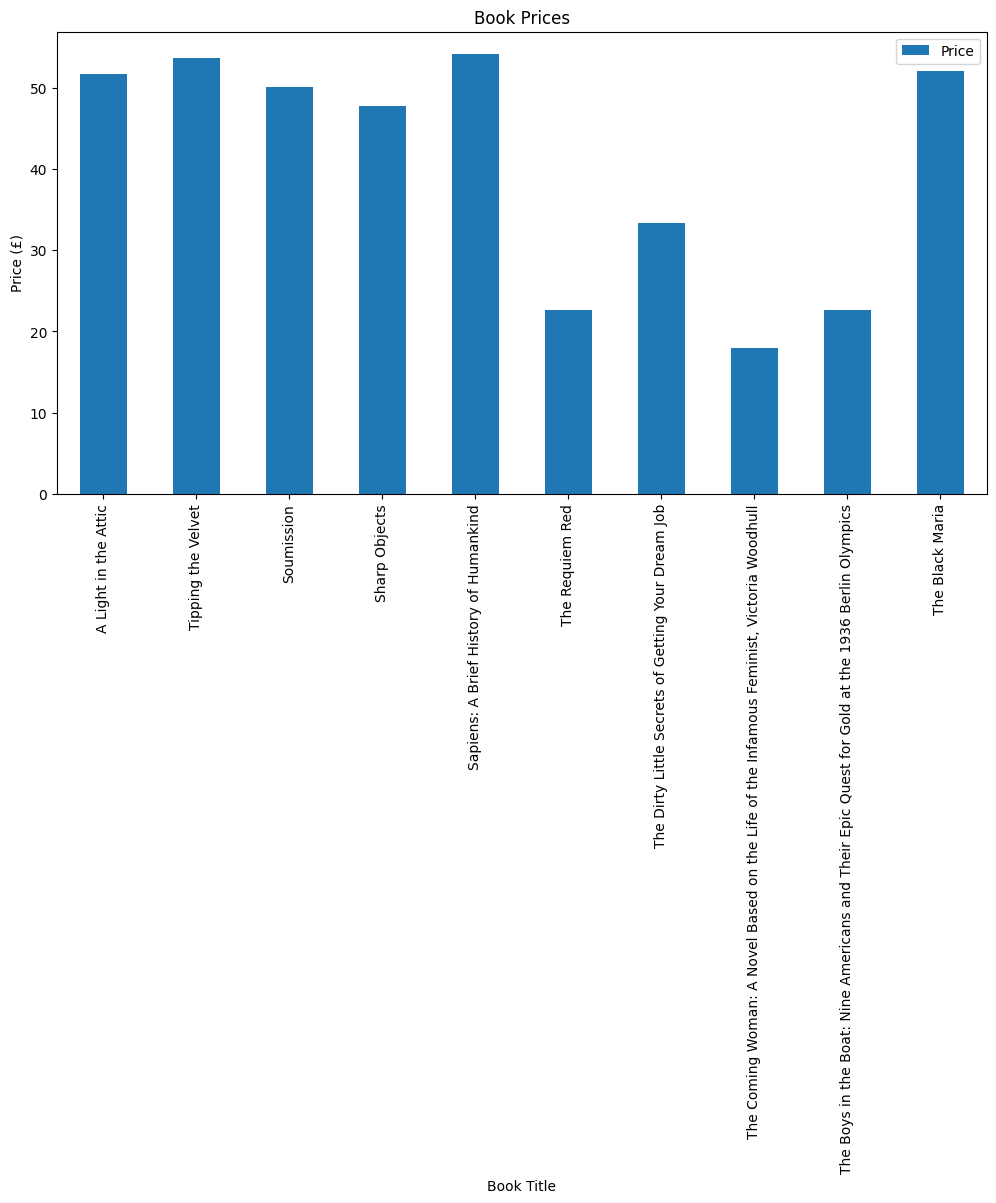

In [13]:
df.head(10).plot(
    x="Title",
    y="Price",
    kind="bar",
    figsize=(12, 6)
)

plt.title("Book Prices")
plt.xlabel("Book Title")
plt.ylabel("Price (£)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()